# 1. Filtering

In [ ]:
import xarray as xr
import numpy as np
import scipy
from matplotlib import pyplot as plt
from depsi.atmosphere_estimation import estimate_unmodeled_displacement

## Load input and output from matlab files

In [2]:
data_input = scipy.io.loadmat("./depsi_matlab_atmo_kriging_testdata/zegveld_s1_t037_ps_filtering_input.mat")
stm = xr.Dataset(
    {
        "psc_phase": (["space", "time"], data_input['psc_phase_res']),
        "years": (["time"], data_input['Btemp'].squeeze()),
    },
).chunk({"space": 10, "time": -1})

In [3]:
data_output = scipy.io.loadmat("./depsi_matlab_atmo_kriging_testdata/zegveld_s1_t037_ps_filtering_output.mat")
non_linear = xr.Dataset(
    {
        "non_linear_matlab": (["space", "time"], data_output['non_linear']),
        "years": (["time"], data_input['Btemp'].squeeze()),
    },
).chunk({"space": 10, "time": -1})

## Inspect other input arguments

In [4]:
print(data_input['ts_atmo_filter'], data_input['ts_atmo_filter_length'])

['gaussian'] [[1]]


## Calculate "non_linear" using Python for comparison

In [7]:
non_linear["non_linear_python"] = estimate_unmodeled_displacement(
        psc_phase_residuals=stm["psc_phase"],
        baseline_years=stm["years"],
        filter_length=1,
        filter_type='gaussian',
    )

## Plot both

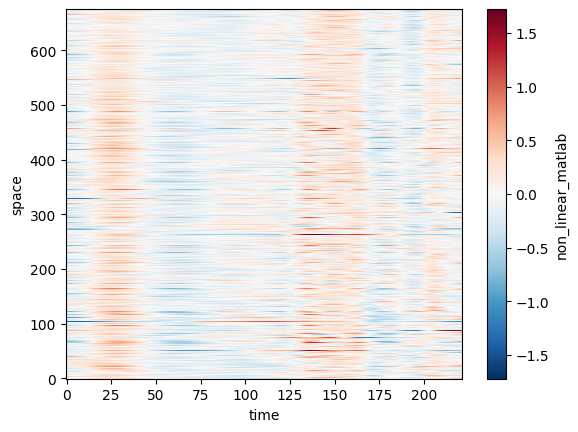

In [8]:
non_linear["non_linear_matlab"].plot(x="time", y="space")

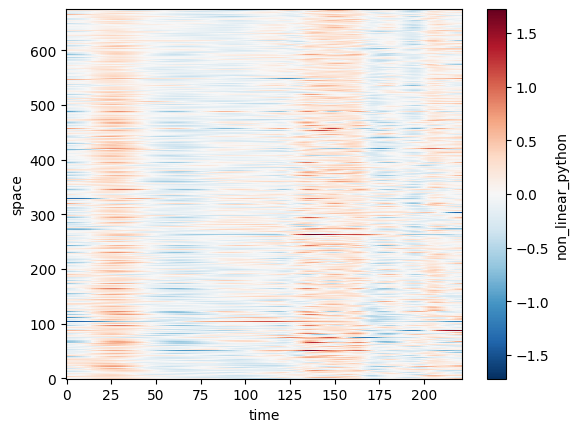

In [9]:
non_linear["non_linear_python"].plot(x="time", y="space")

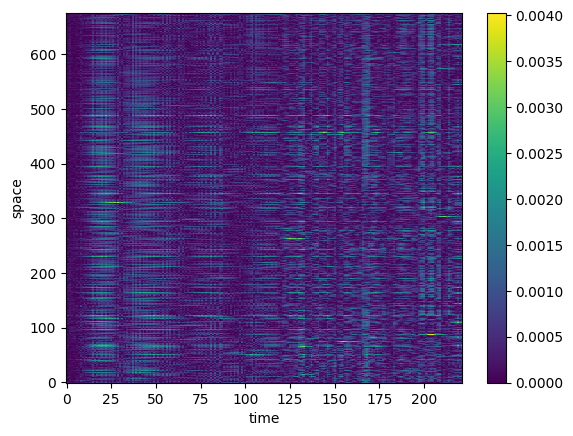

In [10]:
# absolute difference bewteen matlab and python
ae = abs(non_linear["non_linear_python"] - non_linear["non_linear_matlab"])
ae.plot(x="time", y="space")

# 2. Interpolation

In [1]:
import xarray as xr
import numpy as np
import scipy
from matplotlib import pyplot as plt
from depsi.atmosphere_estimation import solve_kriging

In [2]:
data_input = scipy.io.loadmat("./depsi_matlab_atmo_kriging_testdata/zegveld_s1_t037_ps_atmo_kriging_input.mat")
ds = xr.Dataset(
    {
        "ps_atmosphere": (["space", "time"], data_input["atmo_estimates"])
    },
    coords={
        "x": ("space", data_input["psc_azx"].squeeze()),
        "y": ("space", data_input["psc_rx"].squeeze()),
    }
)

In [3]:
data_output = scipy.io.loadmat("./depsi_matlab_atmo_kriging_testdata/zegveld_s1_t037_ps_atmo_kriging_output.mat")

# remove nan values
pcs_atmo_clean = data_output["psc_atmo"][~np.isnan(data_output["psc_atmo"]).any(axis=1)]

result_matlab = xr.Dataset(
    {
        "interpolated": (["space", "time"], pcs_atmo_clean)
    },
    coords={
        "x": ("space", data_input["psc_azx"].squeeze()),
        "y": ("space", data_input["psc_rx"].squeeze()),
    }
)

In [4]:
%%time
points = xr.Dataset(coords = ds.coords)  #points
result_python = solve_kriging(ds["ps_atmosphere"], grid=points, method="universal", n_nearest_neighbors=100)

CPU times: user 2h 33min 9s, sys: 4min 55s, total: 2h 38min 4s
Wall time: 42min 56s


In [5]:
# absolute error
ae = abs(result_matlab["interpolated"] - result_python["interpolated"].isel(time=slice(None, -1)))

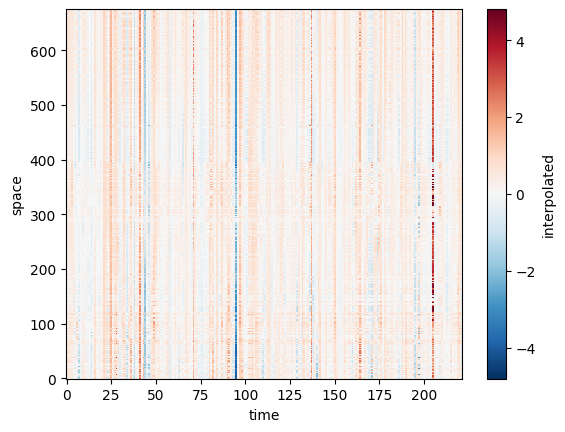

In [6]:
result_python["interpolated"].isel(time=slice(None, -1)).plot(x="time", y="space")

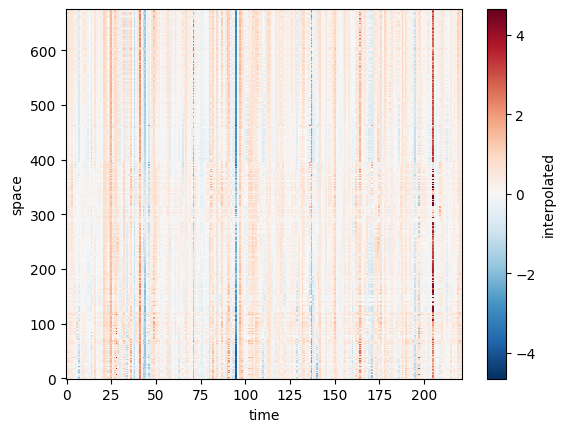

In [7]:
result_matlab["interpolated"].plot(x="time", y="space")

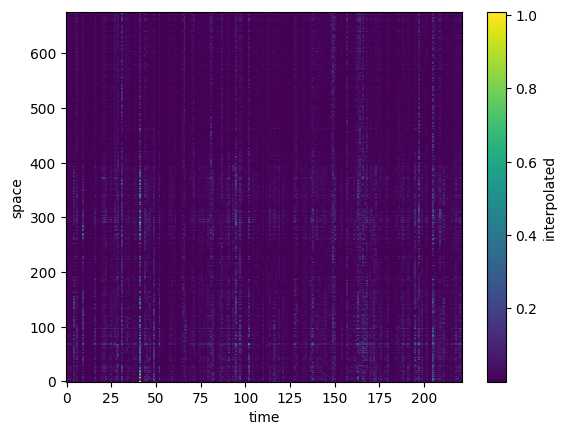

In [8]:
ae.plot(x="time", y="space")